# Voltage session heatmap

This notebook mirrors the glutamate session-heatmap workflow, but reads the voltage asset structure used by the repo:

- raw extraction assets are resolved as `asset.modality_assets["voltage"]` with `summary_mat`, `trace_h5`, and `extraction_dir`;
- plotting-ready session traces are written by voltage extraction to `asset.derived_dir / "voltage" / "voltage_session_traces_<variant>.h5"`;
- each DMD group in that HDF5 file stores ROI-by-time arrays (`raw_f`, `f0`, `dff`) plus `timebase_sec`, `roi_ids`, `valid_rois_mask`, and trial metadata.

The session heatmap below reads only the requested time window and automatically decimates for display, which keeps full-session voltage files usable in the notebook.

In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d

from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

# If imports fail because the repo is not installed/editable, point this at your local clone.
# REPO_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis")
REPO_ROOT = None
if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.plotting.plot_session_heatmap import (
    IM_COLORS,
    DEFAULT_X_TICK_PARAMS,
    DEFAULT_Y_TICK_PARAMS,
    _merge_kwargs,
    _robust_row_zscore,
    _fill_nan_rowwise,
    _smooth_rows,
    _compute_dt,
    _safe_percentiles,
    _build_image_color_map,
    load_stimulus_events,
    load_running_speed,
    build_stimulus_locked_feature_mats,
    compute_sort_orders,
    build_pc1_trace_for_session,
)

In [62]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

## User configuration

In [78]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
    826031,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

## Resolve sessions and voltage assets

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 10 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [113]:
asset = assets[3]
print(asset.session_id)
print("session_dir:", asset.session_dir)
print("derived_dir:", asset.derived_dir)
print("voltage assets:")
for key, path in asset.get_modality_assets("voltage").items():
    print(f"  {key}: {path}")

826031_2026-02-03_14-21-45
session_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\analysis\derived
voltage assets:
  summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\826031_2026-02-03_14-21-45_slap2_2026-02-03_14-21-45\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260625-131820.mat
  trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\826031_2026-02-03_14-21-45_slap2_2026-02-03_14-21-45\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260625-131820.h5
  extraction_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\826031_2026-02-03_14-21-45_slap2_2026-02-03_14-21-45\source_extraction\dendriticVoltageExtraction


## Voltage HDF5 helpers

In [114]:
def resolve_voltage_session_trace_h5(asset, trace_variant="dff_robust_f0_trial", session_trace_h5=None):
    """Resolve a plotting-ready voltage_session_traces_<variant>.h5 file."""
    if session_trace_h5 is not None:
        path = Path(session_trace_h5)
        if not path.exists():
            raise FileNotFoundError(f"SESSION_TRACE_H5 does not exist: {path}")
        return path

    if asset.derived_dir is None:
        raise ValueError("asset.derived_dir is missing; cannot resolve derived voltage traces.")

    voltage_dir = Path(asset.derived_dir) / "voltage"
    preferred = voltage_dir / f"voltage_session_traces_{trace_variant}.h5"
    if preferred.exists():
        return preferred

    matches = sorted(
        voltage_dir.glob("voltage_session_traces_*.h5"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not matches:
        raise FileNotFoundError(
            "No voltage_session_traces_*.h5 file found. Run voltage extraction with "
            "write_session_traces=True, or set SESSION_TRACE_H5 to an existing file.\n"
            f"Looked in: {voltage_dir}"
        )

    print("Preferred trace variant not found:", preferred.name)
    print("Using newest available voltage session trace file:", matches[0].name)
    return matches[0]


def _dmd_sort_key(key):
    digits = "".join(ch for ch in str(key) if ch.isdigit())
    return int(digits) if digits else 999


def _decode_roi_ids(x):
    arr = np.asarray(x)
    out = []
    for val in arr.reshape(-1):
        if isinstance(val, bytes):
            out.append(val.decode(errors="ignore"))
        else:
            out.append(str(val))
    return np.asarray(out, dtype=object)


def inspect_voltage_session_h5(path):
    """Return a compact inventory of DMD groups and datasets in a session-trace H5."""
    rows = []
    path = Path(path)
    with h5py.File(path, "r") as h5:
        root_meta = {}
        for k, v in h5.attrs.items():
            root_meta[k] = v.decode(errors="ignore") if isinstance(v, bytes) else v

        for dmd_key in sorted([k for k in h5.keys() if str(k).startswith("DMD")], key=_dmd_sort_key):
            grp = h5[dmd_key]
            for name, obj in grp.items():
                if isinstance(obj, h5py.Dataset):
                    rows.append({
                        "DMD": dmd_key,
                        "dataset": name,
                        "shape": tuple(obj.shape),
                        "dtype": str(obj.dtype),
                        "chunks": obj.chunks,
                        "compression": obj.compression,
                    })
                elif isinstance(obj, h5py.Group):
                    rows.append({
                        "DMD": dmd_key,
                        "dataset": f"{name}/",
                        "shape": "group",
                        "dtype": "",
                        "chunks": "",
                        "compression": "",
                    })
    return pd.DataFrame(rows)


def _time_zero_abs(t_abs, *, mode, session_start_sec):
    if mode == "imaging_epoch_start":
        return float(session_start_sec)
    if mode == "first_sample":
        return float(np.asarray(t_abs, dtype=float)[0])
    if mode == "none":
        return 0.0
    raise ValueError("timebase_zero must be 'imaging_epoch_start', 'first_sample', or 'none'.")


def _slice_for_xlim(t, xlim_sec):
    t = np.asarray(t, dtype=float)
    if xlim_sec is None:
        return 0, int(t.size)
    lo = int(np.searchsorted(t, float(xlim_sec[0]), side="left"))
    hi = int(np.searchsorted(t, float(xlim_sec[1]), side="right"))
    lo = max(0, min(lo, int(t.size)))
    hi = max(0, min(hi, int(t.size)))
    if hi <= lo:
        raise ValueError(f"No voltage samples in xlim_sec={xlim_sec}")
    return lo, hi


def load_voltage_session_mats(
    asset,
    *,
    trace_variant="dff_robust_f0_trial",
    session_trace_h5=None,
    signal="dff",
    xlim_sec=None,
    max_display_samples_per_dmd=30_000,
    timebase_zero="imaging_epoch_start",
    use_roi_qc=True,
    normalize_rows="zscore",
    dtype=np.float32,
):
    """
    Load DMD-specific ROI-by-time matrices from a derived voltage session H5.

    The H5 stores absolute corrected behavior-time values in timebase_sec. For plotting,
    this function usually subtracts the first imaging-epoch start so the x-axis matches
    the glutamate notebook convention: session time from imaging epoch start.
    """
    stim = load_stimulus_events(asset)
    session_start_sec = float(stim["session_start_sec"])
    path = resolve_voltage_session_trace_h5(
        asset,
        trace_variant=trace_variant,
        session_trace_h5=session_trace_h5,
    )

    dmd_mats = {}
    dmd_timebases = {}
    dmd_dt = {}
    dmd_roi_ids = {}
    dmd_valid_roi_masks = {}
    dmd_source_slices = {}
    zero_abs_values = []

    with h5py.File(path, "r") as h5:
        dmd_keys = sorted([k for k in h5.keys() if str(k).startswith("DMD")], key=_dmd_sort_key)
        if not dmd_keys:
            raise KeyError(f"No DMD groups found in {path}")

        for dmd_key in dmd_keys:
            dmd = _dmd_sort_key(dmd_key)
            grp = h5[dmd_key]
            if signal not in grp:
                available = [k for k, v in grp.items() if isinstance(v, h5py.Dataset)]
                raise KeyError(f"Signal dataset {signal!r} not found in {dmd_key}. Available datasets: {available}")
            if "timebase_sec" not in grp:
                raise KeyError(f"{dmd_key}/timebase_sec not found in {path}")

            t_abs = np.asarray(grp["timebase_sec"][:], dtype=float)
            zero_abs = _time_zero_abs(t_abs, mode=timebase_zero, session_start_sec=session_start_sec)
            zero_abs_values.append(zero_abs)
            t_plot = t_abs - zero_abs

            lo, hi = _slice_for_xlim(t_plot, xlim_sec)
            n_selected = max(1, hi - lo)
            step = max(1, int(np.ceil(n_selected / float(max_display_samples_per_dmd))))
            t_sel = t_plot[lo:hi:step]

            mat = np.asarray(grp[signal][:, lo:hi:step], dtype=dtype)

            if "roi_ids" in grp:
                roi_ids = _decode_roi_ids(grp["roi_ids"][:])
            else:
                roi_ids = np.asarray([f"DMD{dmd}_ROI{i:03d}" for i in range(mat.shape[0])], dtype=object)

            if "valid_rois_mask" in grp:
                valid_mask = np.asarray(grp["valid_rois_mask"][:], dtype=bool).reshape(-1)
            else:
                valid_mask = np.ones((mat.shape[0],), dtype=bool)

            if valid_mask.size != mat.shape[0]:
                aligned = np.ones((mat.shape[0],), dtype=bool)
                n = min(valid_mask.size, mat.shape[0])
                aligned[:n] = valid_mask[:n]
                valid_mask = aligned

            if use_roi_qc:
                mat = mat[valid_mask, :]
                roi_ids = roi_ids[valid_mask]

            mat = np.asarray(mat, dtype=float)
            if normalize_rows == "zscore":
                mat = _robust_row_zscore(mat)
            elif normalize_rows in (None, False, "none"):
                pass
            else:
                raise ValueError("normalize_rows must be 'zscore', None, False, or 'none'.")

            dmd_mats[dmd] = mat
            dmd_timebases[dmd] = t_sel
            dmd_dt[dmd] = _compute_dt(t_sel)
            dmd_roi_ids[dmd] = roi_ids
            dmd_valid_roi_masks[dmd] = valid_mask
            dmd_source_slices[dmd] = {"lo": lo, "hi": hi, "step": step, "n_selected": n_selected}

    # DMDs should share the same time zero; keep the first and warn if not.
    time_zero_abs_sec = float(zero_abs_values[0]) if zero_abs_values else session_start_sec
    if len(zero_abs_values) > 1 and np.nanmax(np.abs(np.asarray(zero_abs_values) - time_zero_abs_sec)) > 1e-6:
        print("Warning: DMD time-zero values differ slightly; using the first DMD for stimulus/running alignment.")

    meta = {
        "session_trace_h5": str(path),
        "trace_variant": trace_variant,
        "signal": signal,
        "timebase_zero": timebase_zero,
        "time_zero_abs_sec": time_zero_abs_sec,
        "session_start_sec": session_start_sec,
        "use_roi_qc": bool(use_roi_qc),
        "normalize_rows": normalize_rows,
        "source_slices": dmd_source_slices,
    }
    return dmd_mats, dmd_timebases, dmd_dt, dmd_roi_ids, meta

In [115]:
session_trace_h5 = resolve_voltage_session_trace_h5(
    asset,
    trace_variant=TRACE_VARIANT,
    session_trace_h5=SESSION_TRACE_H5,
)
print(session_trace_h5)
display(inspect_voltage_session_h5(session_trace_h5))

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-03_14-21-45\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


,DMD,dataset,shape,dtype,chunks,compression
0,DMD1,dff,"(24, 19236073)",float32,"(1, 8192)",gzip
1,DMD1,f0,"(24, 19236073)",float32,"(1, 8192)",gzip
2,DMD1,f0_model/,group,,,
3,DMD1,raw_f,"(24, 19236073)",float32,"(1, 8192)",gzip
4,DMD1,roi_ids,"(24,)",|S12,None,None
5,DMD1,timebase_sec,"(19236073,)",float64,None,None
6,DMD1,trial_lengths_samples,"(193,)",int64,None,None
7,DMD1,trial_starts_sec,"(193,)",float64,None,None
8,DMD1,trial_valid_mask,"(193,)",bool,None,None
9,DMD1,valid_rois_mask,"(24,)",bool,None,None


## Session voltage heatmap

In [116]:
def plot_voltage_session(
    asset,
    *,
    trace_variant="dff_robust_f0_trial",
    session_trace_h5=None,
    signal="dff",
    xlim_sec=None,
    max_display_samples_per_dmd=30_000,
    timebase_zero="imaging_epoch_start",
    use_roi_qc=True,
    normalize_rows="zscore",
    display_smooth_sigma=1.0,
    feature_smooth_sigma=2.0,
    sort_by="pc1_raw",
    show_image_bar=True,
    show_sort_trace=False,
    sort_trace_source_dmd=None,
    sort_trace_height=0.7,
    show_running_trace=False,
    running_trace_height=0.7,
    encoder_path=None,
    encoder_col="Encoder",
    wheel_radius_cm=8.225,
    encoder_units="cm",
    speed_units="cm/s",
    running_median_filter_kernel=75,
    running_absolute_speed=True,
    ticks_per_revolution=None,
    running_smooth_speed_sigma=12.0,
    running_time_zero="first_sample",
    running_time_offset_sec=None,
    running_empty_message=True,
    running_ylim_percentile=99.5,
    image_flash_duration=0.25,
    im_colors=IM_COLORS,
    cmap_session="coolwarm",
    session_percentiles=(2, 98),
    figsize_width=16,
    roi_height=0.12,
    min_whole_height=0.6,
    image_bar_height=0.35,
    dmd_gap_height=0.24,
    show_row_labels=True,
    image_bar_ylabel="Image",
    session_xlabel="Session time from imaging epoch start (s)",
    session_ylabel_template="DMD {dmd}\n{n_roi} ROI",
    running_ylabel="Speed\n(cm/s)",
    sort_trace_ylabel="PC1",
    cbar_label=None,
    label_kwargs=None,
    image_bar_ylabel_kwargs=None,
    session_xlabel_kwargs=None,
    session_ylabel_kwargs=None,
    running_ylabel_kwargs=None,
    sort_trace_ylabel_kwargs=None,
    cbar_label_kwargs=None,
    x_tick_params=None,
    y_tick_params=None,
    rastermap_kwargs=None,
    sharex=True,
):
    """Plot a DMD-split heatmap from derived full-session voltage traces."""
    stim = load_stimulus_events(asset)
    ordered_images = stim["ordered_images"]

    dmd_mats, dmd_timebases, dmd_dt, dmd_roi_ids, meta = load_voltage_session_mats(
        asset,
        trace_variant=trace_variant,
        session_trace_h5=session_trace_h5,
        signal=signal,
        xlim_sec=xlim_sec,
        max_display_samples_per_dmd=max_display_samples_per_dmd,
        timebase_zero=timebase_zero,
        use_roi_qc=use_roi_qc,
        normalize_rows=normalize_rows,
    )

    sort_needs_stim = sort_by in {
        "stimulus_locked_per_image",
        "stimulus_locked_pooled",
        "pc1_per_image",
        "pc1_pooled",
        "rastermap_per_image",
        "rastermap_pooled",
    }
    if sort_needs_stim:
        features = build_stimulus_locked_feature_mats(
            dmd_mats=dmd_mats,
            dmd_timebases=dmd_timebases,
            dmd_dt=dmd_dt,
            ordered_images=ordered_images,
            session_start_sec=meta["time_zero_abs_sec"],
            t_pre=0.5,
            t_post=1.0,
            baseline_subtract=True,
            baseline_window=(-0.25, 0.0),
            smooth_sigma=feature_smooth_sigma,
        )
    else:
        # Placeholder dicts keep compute_sort_orders happy for raw/PC1/correlation sorting.
        features = {
            "pooled": {d: dmd_mats[d] for d in dmd_mats},
            "per_image": {d: dmd_mats[d] for d in dmd_mats},
            "t_rel": {d: dmd_timebases[d] for d in dmd_mats},
            "unique_images": [],
        }

    sort_info = compute_sort_orders(
        dmd_mats=dmd_mats,
        features=features,
        sort_by=sort_by,
        feature_smooth_sigma=feature_smooth_sigma,
        rastermap_kwargs=rastermap_kwargs,
    )
    dmd_order = sort_info["dmd_order"]
    dmd_sort_meta = sort_info["dmd_sort_meta"]

    dmds = sorted(dmd_mats.keys())
    dmd_session = {}
    dmd_display_time = {}
    dmd_display_roi_ids = {}
    for dmd in dmds:
        mat = dmd_mats[dmd][dmd_order[dmd]]
        mat = _smooth_rows(mat, display_smooth_sigma)
        dmd_session[dmd] = mat
        dmd_display_time[dmd] = dmd_timebases[dmd]
        dmd_display_roi_ids[dmd] = dmd_roi_ids[dmd][dmd_order[dmd]]

    session_vals = np.concatenate([np.ravel(np.nan_to_num(dmd_session[d], nan=0.0)) for d in dmds])
    svmin, svmax = _safe_percentiles(session_vals, session_percentiles)

    if sort_trace_source_dmd is None:
        sort_trace_source_dmd = dmds[0]

    x0 = float(dmd_display_time[dmds[0]][0])
    x1 = float(dmd_display_time[dmds[0]][-1])

    pc1_trace = None
    if show_sort_trace and sort_by == "pc1_raw":
        pc1_trace = build_pc1_trace_for_session(
            session_mat=dmd_mats[sort_trace_source_dmd],
            session_t=dmd_timebases[sort_trace_source_dmd],
            smooth_sigma=feature_smooth_sigma,
        )

    running = None
    if show_running_trace:
        # Timebase convention:
        #   - voltage timebase_sec is in photodiode/HARP-relative seconds
        #   - encoder.pkl keeps the raw HARP clock in its index
        #   - compute_encoder_velocity(time_zero="first_sample") converts encoder time
        #     to the same approximately photodiode-relative coordinate
        #   - subtract meta["time_zero_abs_sec"] so running is plotted on the same
        #     x-axis as the voltage heatmap.
        if running_time_offset_sec is None:
            running_offset = -float(meta["time_zero_abs_sec"])
        else:
            running_offset = float(running_time_offset_sec)

        running = load_running_speed(
            asset=asset,
            session_start_sec=float(stim["session_start_sec"]),
            xlim_sec=(x0, x1),
            encoder_path=encoder_path,
            encoder_col=encoder_col,
            wheel_radius_cm=wheel_radius_cm,
            encoder_units=encoder_units,
            speed_units=speed_units,
            median_filter_kernel=running_median_filter_kernel,
            absolute_speed=running_absolute_speed,
            ticks_per_revolution=ticks_per_revolution,
            smooth_speed_sigma=running_smooth_speed_sigma,
            time_zero=running_time_zero,
            time_offset_sec=running_offset,
        )

        if np.asarray(running.get("time_sec", [])).size == 0:
            vel = running.get("encoder_velocity", {})
            full_t = np.asarray(vel.get("time_sec", []), dtype=float) if isinstance(vel, dict) else np.asarray([])
            if full_t.size:
                warnings.warn(
                    "No encoder samples overlap the plotted voltage xlim "
                    f"{(x0, x1)} after time alignment. Full aligned encoder time range is "
                    f"{(float(np.nanmin(full_t)), float(np.nanmax(full_t)))}. "
                    "Check running_time_zero/running_time_offset_sec and the imaging epoch timebase."
                )
            else:
                warnings.warn("No encoder samples were available for the running trace.")

    rows = []
    heights = []
    if show_running_trace:
        rows.append(("running", dmds[0]))
        heights.append(running_trace_height)
    if show_sort_trace and pc1_trace is not None:
        rows.append(("sort_trace", dmds[0]))
        heights.append(sort_trace_height)
    if show_image_bar:
        rows.append(("image", dmds[0]))
        heights.append(image_bar_height)
    for i, dmd in enumerate(dmds):
        n_roi = dmd_session[dmd].shape[0]
        rows.append(("whole", dmd))
        heights.append(max(min_whole_height, n_roi * roi_height))
        if i < len(dmds) - 1:
            rows.append(("gap", dmd))
            heights.append(dmd_gap_height)

    fig = plt.figure(figsize=(figsize_width, sum(heights) + 0.4), constrained_layout=True)
    gs = GridSpec(
        nrows=len(rows),
        ncols=2,
        figure=fig,
        width_ratios=[40, 1.4],
        height_ratios=heights,
    )

    axes = {}
    shared_x_master = None
    session_im = None
    for r, (kind, dmd) in enumerate(rows):
        if kind == "gap":
            ax = fig.add_subplot(gs[r, 0])
            ax.axis("off")
            axes[(kind, dmd)] = ax
            continue

        # Share the x-axis across every data-bearing panel: running, sort trace,
        # image bar, and all DMD heatmaps.  This must use the first non-gap axis
        # as the master; the previous implementation used the first DMD heatmap,
        # so panels placed above it were created before the shared axis existed.
        if sharex and shared_x_master is not None:
            ax = fig.add_subplot(gs[r, 0], sharex=shared_x_master)
        else:
            ax = fig.add_subplot(gs[r, 0])
            if sharex and shared_x_master is None:
                shared_x_master = ax
        axes[(kind, dmd)] = ax

    label_kwargs = dict(label_kwargs or {})
    image_bar_ylabel_kwargs = _merge_kwargs(label_kwargs, image_bar_ylabel_kwargs)
    session_xlabel_kwargs = _merge_kwargs(label_kwargs, session_xlabel_kwargs)
    session_ylabel_kwargs = _merge_kwargs(label_kwargs, session_ylabel_kwargs)
    running_ylabel_kwargs = _merge_kwargs(label_kwargs, running_ylabel_kwargs)
    sort_trace_ylabel_kwargs = _merge_kwargs(label_kwargs, sort_trace_ylabel_kwargs)
    cbar_label_kwargs = _merge_kwargs(label_kwargs, cbar_label_kwargs)
    x_tick_params = _merge_kwargs(DEFAULT_X_TICK_PARAMS, x_tick_params)
    y_tick_params = _merge_kwargs(DEFAULT_Y_TICK_PARAMS, y_tick_params)

    if show_running_trace and running is not None:
        ax = axes[("running", dmds[0])]
        rt = np.asarray(running.get("time_sec", []), dtype=float)
        rs = np.asarray(running.get("speed", []), dtype=float)
        if rt.size and rs.size:
            ax.plot(rt, rs, color="k", lw=0.8)
            finite_speed = rs[np.isfinite(rs)]
            if finite_speed.size and running_ylim_percentile is not None:
                ymax = float(np.nanpercentile(finite_speed, running_ylim_percentile))
                if np.isfinite(ymax) and ymax > 0:
                    ax.set_ylim(0, ymax * 1.10)
        elif running_empty_message:
            ax.text(
                0.5, 0.5,
                "No running samples overlap plotted x-limits",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
            )
        ax.set_xlim(x0, x1)
        ax.set_ylabel(running_ylabel, **running_ylabel_kwargs)
        ax.tick_params(**x_tick_params)
        ax.tick_params(**y_tick_params)
        ax.tick_params(axis="x", labelbottom=False)

    if show_sort_trace and pc1_trace is not None:
        ax = axes[("sort_trace", dmds[0])]
        ax.plot(pc1_trace["time_sec"], pc1_trace["trace"], color="k", lw=0.8)
        ax.set_xlim(x0, x1)
        ax.set_ylabel(sort_trace_ylabel, **sort_trace_ylabel_kwargs)
        ax.tick_params(**x_tick_params)
        ax.tick_params(**y_tick_params)
        ax.tick_params(axis="x", labelbottom=False)

    if show_image_bar:
        ax = axes[("image", dmds[0])]
        color_map = _build_image_color_map(ordered_images, im_colors)
        for evt in ordered_images:
            onset_rel = float(evt.onset) - float(meta["time_zero_abs_sec"])
            if onset_rel + image_flash_duration < x0 or onset_rel > x1:
                continue
            ax.axvspan(
                onset_rel,
                onset_rel + image_flash_duration,
                color=color_map.get(evt.image_name, "#cccccc"),
                lw=0,
                alpha=1.0,
            )
        ax.set_xlim(x0, x1)
        ax.set_yticks([])
        ax.set_ylabel(image_bar_ylabel, rotation=0, ha="right", va="center", labelpad=14, **image_bar_ylabel_kwargs)
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
        for side in ("left", "right", "top"):
            ax.spines[side].set_visible(False)

    last_whole_ax = None
    for dmd in dmds:
        n_roi = dmd_session[dmd].shape[0]
        left_label = session_ylabel_template.format(dmd=dmd, n_roi=n_roi, n_rois=n_roi)
        ax = axes[("whole", dmd)]
        t = dmd_display_time[dmd]
        mat = np.nan_to_num(dmd_session[dmd], nan=0.0)
        im = ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap_session,
            vmin=svmin,
            vmax=svmax,
            extent=[t[0], t[-1], mat.shape[0], 0],
        )
        if session_im is None:
            session_im = im
        ax.set_ylabel(left_label if show_row_labels else "", **session_ylabel_kwargs)
        ax.tick_params(**x_tick_params)
        ax.tick_params(**y_tick_params)
        ax.tick_params(axis="x", labelbottom=False)
        last_whole_ax = ax

    if last_whole_ax is not None:
        last_whole_ax.tick_params(axis="x", labelbottom=True)
        last_whole_ax.set_xlabel(session_xlabel, **session_xlabel_kwargs)

    cax = fig.add_subplot(gs[0, 1])
    if session_im is not None:
        cb = fig.colorbar(session_im, cax=cax)
        if cbar_label is None:
            cbar_label = signal + (" (row z-score)" if normalize_rows == "zscore" else "")
        cb.set_label(cbar_label, **cbar_label_kwargs)
        cb.ax.tick_params(labelsize=y_tick_params.get("labelsize", 12))
    else:
        cax.axis("off")
        cb = None

    return {
        "fig": fig,
        "axes": axes,
        "dmd_order": dmd_order,
        "dmd_sort_meta": dmd_sort_meta,
        "dmd_session": dmd_session,
        "dmd_display_time": dmd_display_time,
        "dmd_display_roi_ids": dmd_display_roi_ids,
        "session_cbar": cb,
        "shared_x_master": shared_x_master,
        "stimulus_events": stim,
        "pc1_trace": pc1_trace,
        "running": running,
        "metadata": meta,
    }

<IPython.core.display.Javascript object>


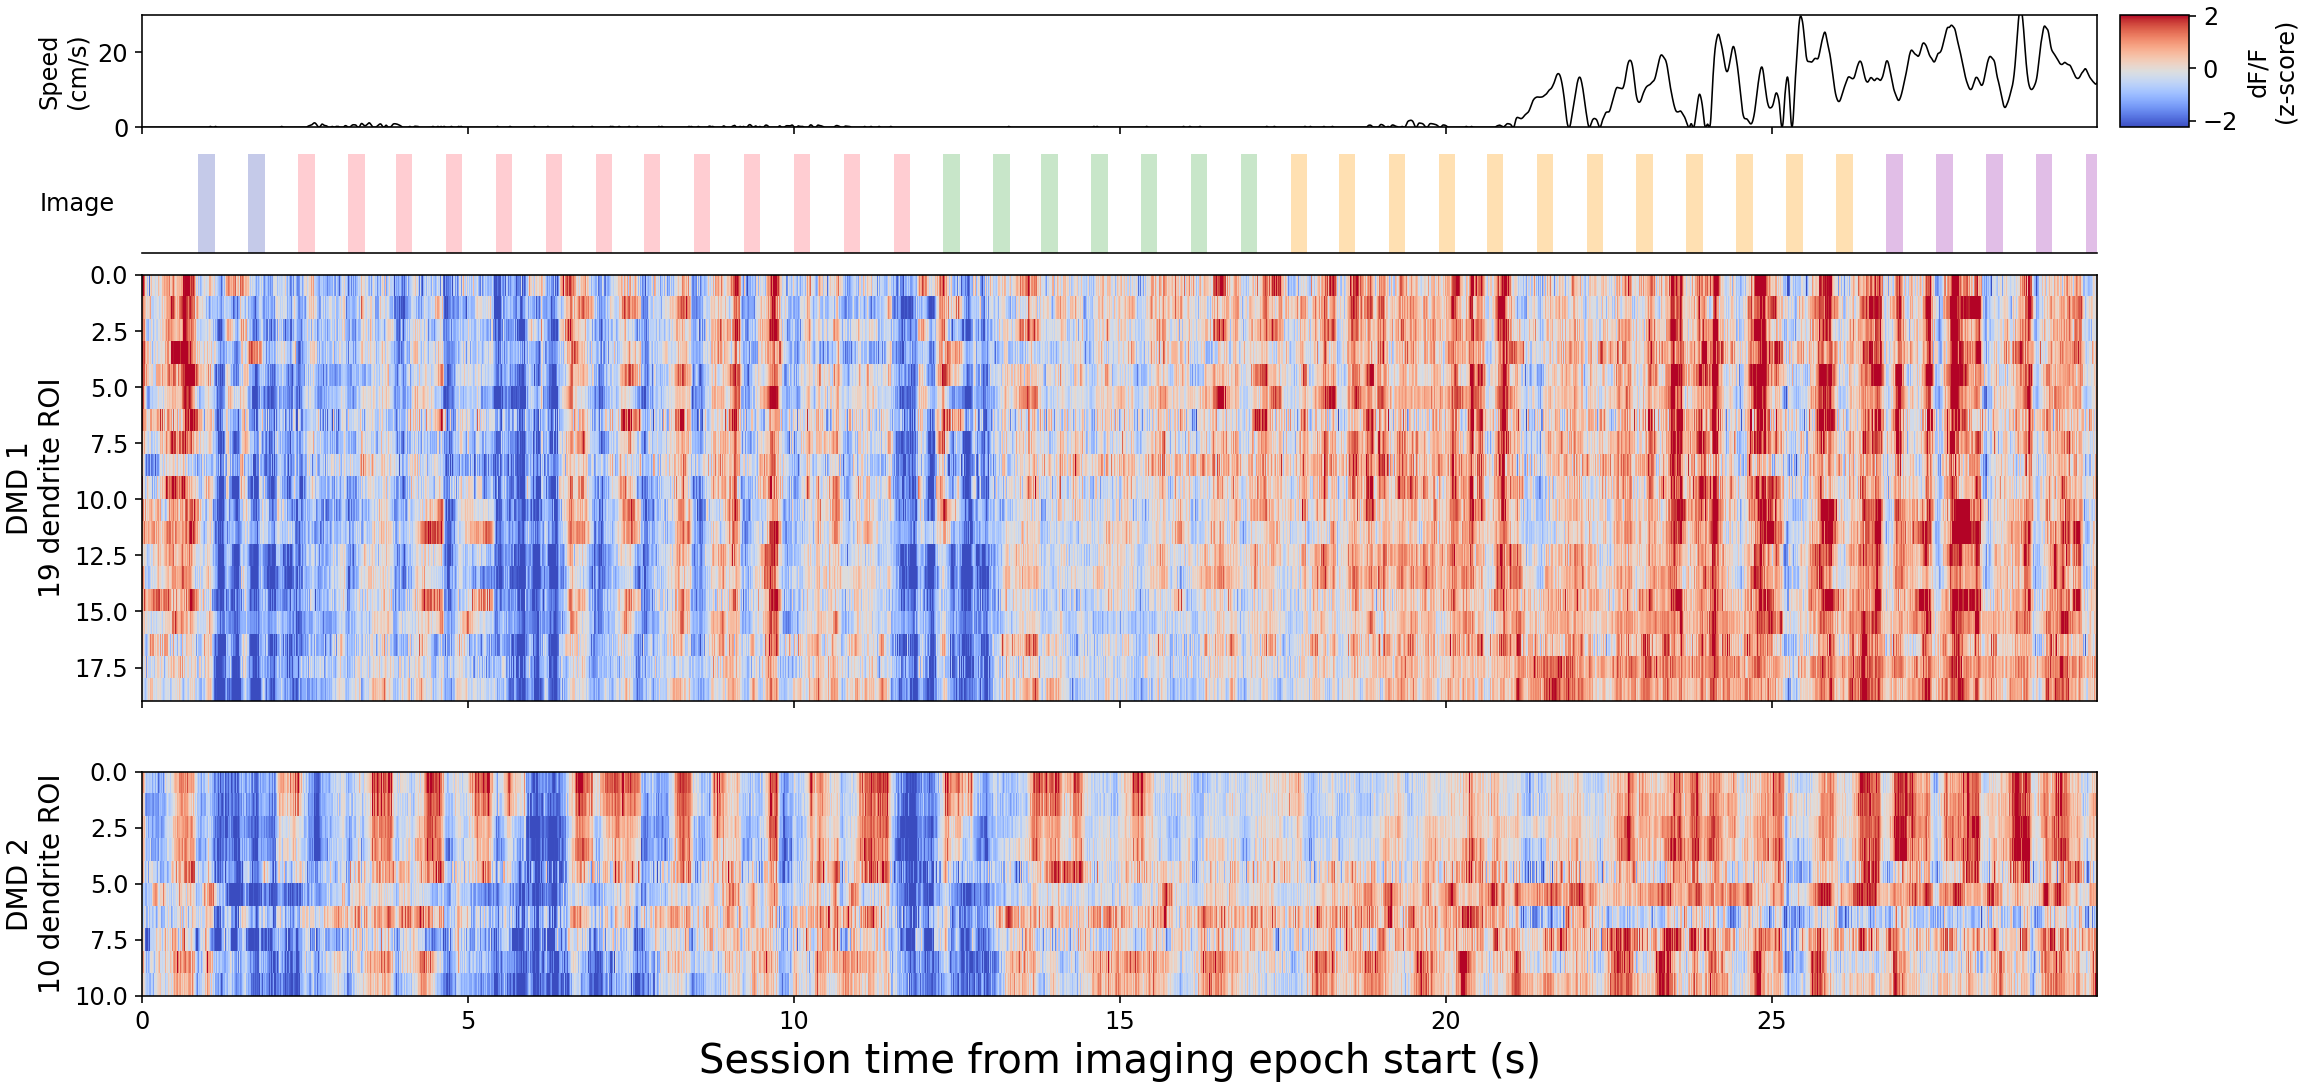

In [117]:
tpr = 8192 

out = plot_voltage_session(
    asset=asset,
    trace_variant=TRACE_VARIANT,
    session_trace_h5=SESSION_TRACE_H5,
    signal=SIGNAL,
    xlim_sec=(0, 30),
    max_display_samples_per_dmd=30_000,
    timebase_zero="imaging_epoch_start",
    use_roi_qc=True,
    normalize_rows="zscore",
    display_smooth_sigma=1.0,
    feature_smooth_sigma=2.0,
    sort_by="pc1_raw",   # try also: "raw_correlation", "pc1_per_image", "stimulus_locked_per_image", None
    show_image_bar=True,
    show_sort_trace=False,
    sort_trace_source_dmd=1,
    show_running_trace=True,
    encoder_units="ticks",
    speed_units="cm/s",
    ticks_per_revolution = tpr,
    running_median_filter_kernel=100,
    running_time_zero="first_sample",
    running_time_offset_sec=None,  # None => subtract voltage time-zero from first-sample-relative encoder time
    wheel_radius_cm=8.225,
    image_flash_duration=0.25,
    cmap_session="coolwarm",
    session_percentiles=(2, 98),
    figsize_width=16,
    roi_height=0.18,
    min_whole_height=0.7,
    image_bar_height=0.8,
    running_trace_height=0.9,
    sort_trace_height=0.9,
    show_row_labels=True,
    image_bar_ylabel="Image",
    running_ylabel="Speed\n(cm/s)",
    sort_trace_ylabel="PC1",
    session_xlabel="Session time from imaging epoch start (s)",
    session_ylabel_template="DMD {dmd}\n{n_roi} dendrite ROI",
    cbar_label="dF/F\n(z-score)",
    label_kwargs={"fontsize": 12},
    image_bar_ylabel_kwargs={"fontsize": 12},
    running_ylabel_kwargs={"fontsize": 12},
    sort_trace_ylabel_kwargs={"fontsize": 12},
    session_xlabel_kwargs={"fontsize": 20},
    session_ylabel_kwargs={"fontsize": 14},
    cbar_label_kwargs={"fontsize": 12},
    x_tick_params={"labelsize": 12, "top": False},
    y_tick_params={"labelsize": 12, "right": False},
)

fig = out["fig"]
fig.patch.set_alpha(0)
filen = f"{today_str}_{asset.session_id}_voltage_session_heatmap_{TRACE_VARIANT}_{SIGNAL}"
SAVE_PATH.mkdir(parents=True, exist_ok=True)
# save_figure(fig, str(SAVE_PATH / filen), formats=[".pdf"], dpi=300)

In [118]:
# Running trace diagnostics
# Use this if the speed panel is blank or looks too flat.
running = out.get("running")
if running is not None:
    rt = np.asarray(running.get("time_sec", []), dtype=float)
    rs = np.asarray(running.get("speed", []), dtype=float)
    vel = running.get("encoder_velocity", {})
    full_t = np.asarray(vel.get("time_sec", []), dtype=float) if isinstance(vel, dict) else np.asarray([])
    full_s = np.asarray(vel.get("linear_speed_cm_s", []), dtype=float) if isinstance(vel, dict) else np.asarray([])

    print(f"Plotted running samples: {rt.size}")
    if rt.size:
        print(f"Plotted running time range: {np.nanmin(rt):.3f} to {np.nanmax(rt):.3f} s")
        print(f"Plotted speed percentiles ({SPEED_UNITS if 'SPEED_UNITS' in globals() else 'cm/s'}): "
              f"{np.nanpercentile(rs, [0, 50, 95, 99, 99.5])}")
    if full_t.size:
        print(f"Full aligned encoder time range: {np.nanmin(full_t):.3f} to {np.nanmax(full_t):.3f} s")
    if isinstance(vel, dict):
        print(f"Counter period inferred: {vel.get('counter_period')}")
        print(f"Number of counter wraps corrected: {vel.get('n_wraps')}")
        if full_s.size:
            print(f"Full speed percentiles (cm/s): {np.nanpercentile(full_s, [0, 50, 95, 99, 99.5])}")
else:
    print("No running dictionary was returned. Set show_running_trace=True and check encoder_path/asset.photodiode_pkl.")


Plotted running samples: 29999
Plotted running time range: 0.001 to 29.999 s
Plotted speed percentiles (cm/s): [ 0.          0.03693021 19.31012593 26.46160032 27.1375318 ]
Full aligned encoder time range: -3.235 to 1796.908 s
Counter period inferred: 65536.0
Number of counter wraps corrected: 17
Full speed percentiles (cm/s): [ 0.          0.13819424 24.30761334 35.17329033 38.9186541 ]


## Optional: list stimulus image identities from behavior QC

In [119]:
behavior_qc_matches = glob.glob(str(Path(asset.qc_dir) / "behavior" / "behavior_validation.json"))
if behavior_qc_matches:
    with open(behavior_qc_matches[0], "r") as f:
        b_qc = json.load(f)
    im_names = b_qc.get("bonsai_validation", {}).get("stimulus_names", [])
else:
    im_names = []

im_names

['stimuli\\images_A\\imk00459.tiff',
 'stimuli\\images_A\\imk00895.tiff',
 'stimuli\\images_A\\imk00942.tiff',
 'stimuli\\images_A\\imk01057.tiff',
 'stimuli\\images_A\\imk01097.tiff',
 'stimuli\\images_A\\imk01378.tiff',
 'stimuli\\images_A\\imk01643.tiff']

## Optional: mean image-locked voltage response heatmap

This uses the extraction summary file `voltage_mean_<variant>.npz`, not the full session trace H5. It is useful for checking image-locked structure after the voltage extraction pathway has run.

In [120]:
def resolve_voltage_mean_npz(asset, trace_variant="dff_robust_f0_trial", mean_npz=None):
    if mean_npz is not None:
        path = Path(mean_npz)
        if not path.exists():
            raise FileNotFoundError(path)
        return path
    path = Path(asset.derived_dir) / "voltage" / f"voltage_mean_{trace_variant}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Mean voltage NPZ not found: {path}\n"
            "Run voltage extraction with write_sequence/write_single_trials as needed, or point mean_npz at an existing file."
        )
    return path


def load_voltage_mean_npz(asset, trace_variant="dff_robust_f0_trial", mean_npz=None):
    path = resolve_voltage_mean_npz(asset, trace_variant=trace_variant, mean_npz=mean_npz)
    pkg = np.load(path, allow_pickle=True)["data"][0]
    return pkg, path


def _coerce_event_mat_timebase(mat, t, *, context="event response"):
    """Return a 2-D ROI-by-time matrix and 1-D timebase with matching time lengths.

    Existing voltage_mean_*.npz files can have a one-sample mismatch because the
    extraction summary uses rounded sample counts while its saved time vector was
    generated with np.arange over floating-point endpoints. For plotting, the
    safest behavior is to preserve the event matrix and trim the longer axis.
    """
    mat = np.asarray(mat, dtype=float)
    t = np.asarray(t, dtype=float).reshape(-1)

    if mat.ndim != 2:
        raise ValueError(f"Expected a 2-D ROI-by-time matrix for {context}; got shape {mat.shape}")
    if t.ndim != 1 or t.size == 0:
        raise ValueError(f"Expected a non-empty 1-D timebase for {context}; got shape {t.shape}")

    n_mat = int(mat.shape[1])
    n_t = int(t.size)
    if n_mat == n_t:
        return mat, t

    n = min(n_mat, n_t)
    print(
        f"Warning: {context} has {n_mat} matrix time samples but {n_t} timebase samples; "
        f"trimming both to {n}."
    )
    return mat[:, :n], t[:n]


def _baseline_subtract_mat(mat, t, baseline_window=(-0.25, 0.0)):
    mat, t = _coerce_event_mat_timebase(mat, t, context="baseline subtraction")
    mask = (t >= baseline_window[0]) & (t < baseline_window[1])
    if not np.any(mask):
        print(f"Warning: no baseline samples found in baseline_window={baseline_window}; skipping baseline subtraction.")
        return mat
    baseline = np.nanmean(mat[:, mask], axis=1, keepdims=True)
    return mat - baseline


def plot_voltage_mean_image_response_heatmap(
    asset,
    *,
    trace_variant="dff_robust_f0_trial",
    mean_npz=None,
    dmd=1,
    image_name=None,
    use_roi_qc=True,
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=2.0,
    sort_by="pc1_raw",
    cmap="coolwarm",
    percentiles=(2, 98),
    figsize=(4, 4),
    xlabel="Time from image onset (s)",
    ylabel="Dendrite ROI",
    cbar_label="Mean voltage response",
    label_kwargs=None,
    title_kwargs=None,
    cbar_label_kwargs=None,
    x_tick_params=None,
    y_tick_params=None,
):
    pkg, path = load_voltage_mean_npz(asset, trace_variant=trace_variant, mean_npz=mean_npz)
    dmd_key = f"DMD{int(dmd)}"
    if dmd_key not in pkg or "image_identity" not in pkg[dmd_key]:
        raise KeyError(f"{dmd_key}/image_identity not found in {path}")

    image_dict = pkg[dmd_key]["image_identity"]
    if image_name is None:
        image_name = next(iter(image_dict.keys()))
    if image_name not in image_dict:
        raise KeyError(f"Image {image_name!r} not found. Available images: {list(image_dict.keys())}")

    mat = np.asarray(image_dict[image_name]["mean"], dtype=float)
    t = np.asarray(pkg["timebase_sec"]["image"], dtype=float)

    if use_roi_qc and "valid_rois_mask" in pkg[dmd_key]:
        mask = np.asarray(pkg[dmd_key]["valid_rois_mask"], dtype=bool).reshape(-1)
        if mask.size == mat.shape[0]:
            mat = mat[mask]
        else:
            print(
                f"Warning: valid_rois_mask length {mask.size} does not match matrix rows {mat.shape[0]}; "
                "plotting without applying ROI QC mask."
            )

    mat, t = _coerce_event_mat_timebase(mat, t, context=f"{dmd_key}/{image_name}")

    if baseline_subtract:
        mat = _baseline_subtract_mat(mat, t, baseline_window=baseline_window)
    if normalize_rows == "zscore":
        mat = _robust_row_zscore(mat)
    elif normalize_rows in (None, False, "none"):
        pass
    else:
        raise ValueError("normalize_rows must be 'zscore', None, False, or 'none'.")

    mat = _smooth_rows(mat, smooth_sigma)

    if sort_by is not None:
        sort_info = compute_sort_orders(
            dmd_mats={int(dmd): mat},
            features={"pooled": {int(dmd): mat}, "per_image": {int(dmd): mat}},
            sort_by=sort_by,
            feature_smooth_sigma=0,
        )
        order = sort_info["dmd_order"][int(dmd)]
        mat = mat[order]
    else:
        order = np.arange(mat.shape[0])

    vmin, vmax = _safe_percentiles(mat, percentiles)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(
        np.nan_to_num(mat, nan=0.0),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[t[0], t[-1], mat.shape[0], 0],
    )
    ax.axvline(0, color="k", lw=0.8, alpha=0.8)

    label_kwargs = dict(label_kwargs or {})
    title_kwargs = _merge_kwargs(label_kwargs, title_kwargs)
    cbar_label_kwargs = _merge_kwargs(label_kwargs, cbar_label_kwargs)
    x_tick_params = _merge_kwargs(DEFAULT_X_TICK_PARAMS, x_tick_params)
    y_tick_params = _merge_kwargs(DEFAULT_Y_TICK_PARAMS, y_tick_params)

    ax.set_xlabel(xlabel, **label_kwargs)
    ax.set_ylabel(ylabel, **label_kwargs)
    ax.set_title(f"{dmd_key}: {os.path.basename(str(image_name))}", **title_kwargs)
    ax.tick_params(**x_tick_params)
    ax.tick_params(**y_tick_params)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(cbar_label, **cbar_label_kwargs)
    
    fig.tight_layout()
    return {"fig": fig, "ax": ax, "cbar": cb, "data": mat, "timebase_sec": t, "image_name": image_name, "path": path, "order": order}

<IPython.core.display.Javascript object>


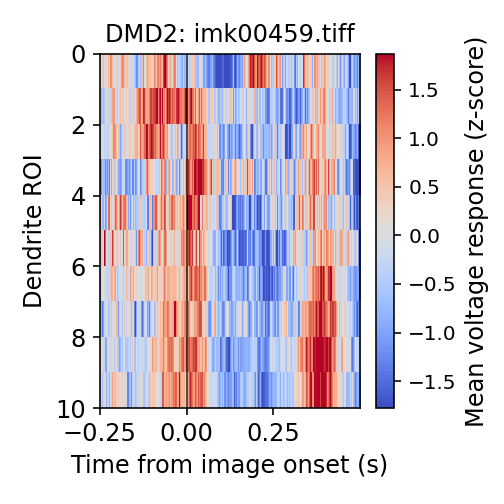

<IPython.core.display.Javascript object>


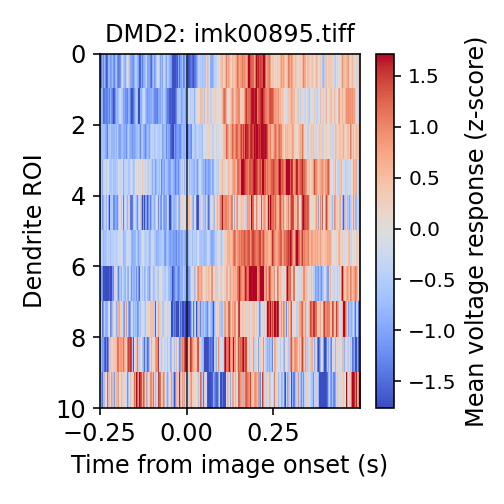

<IPython.core.display.Javascript object>


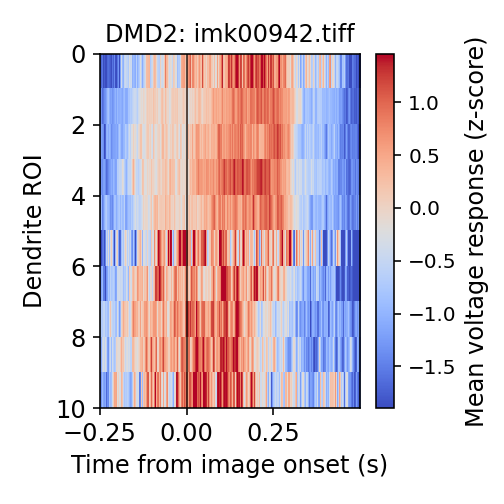

<IPython.core.display.Javascript object>


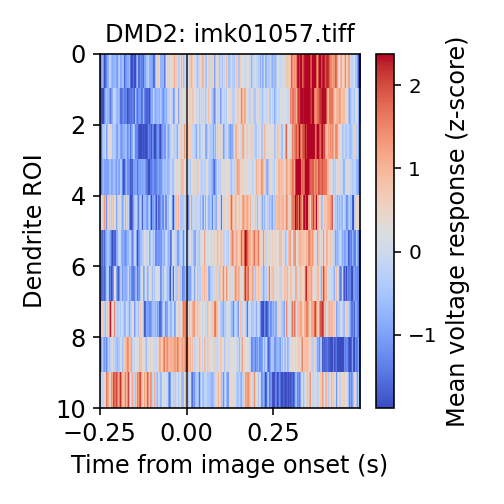

<IPython.core.display.Javascript object>


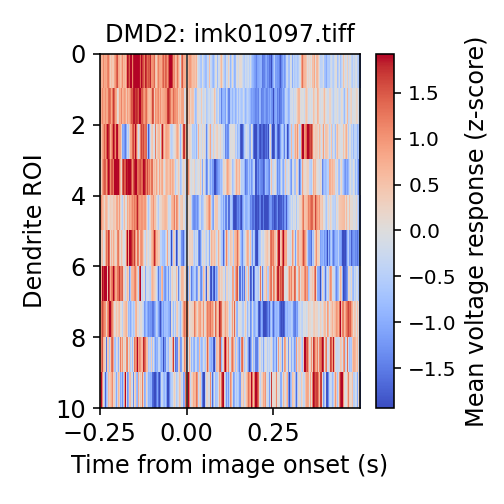

<IPython.core.display.Javascript object>


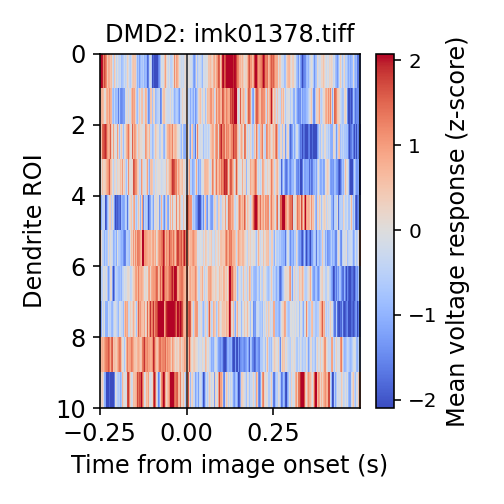

<IPython.core.display.Javascript object>


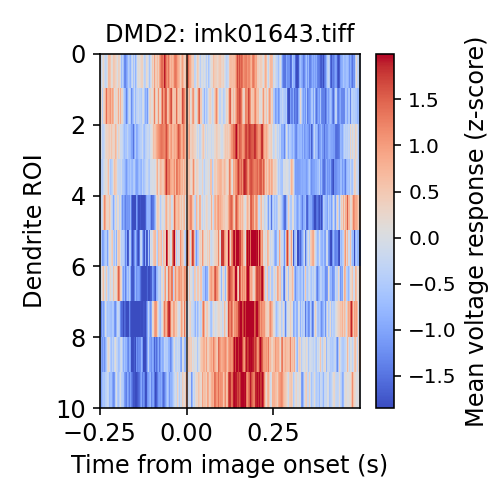

In [122]:
dmd = 2

for image in range(len(im_names)):
    im_idx = image

    if im_names:
        image_name = im_names[im_idx]
    else:
        image_name = None

    try:
        out = plot_voltage_mean_image_response_heatmap(
            asset=asset,
            trace_variant=TRACE_VARIANT,
            dmd=dmd,
            image_name=image_name,
            use_roi_qc=True,
            normalize_rows="zscore",
            baseline_subtract=True,
            baseline_window=(-0.25, 0.0),
            smooth_sigma=5,
            sort_by="pc1_raw",
            cmap="coolwarm",
            percentiles=(2, 98),
            figsize=(3.5, 3.5),
            xlabel="Time from image onset (s)",
            ylabel="Dendrite ROI",
            cbar_label="Mean voltage response (z-score)",
            label_kwargs={"fontsize": 12},
            title_kwargs={"fontsize": 12},
            cbar_label_kwargs={"fontsize": 12},
            x_tick_params=dict(axis="x", which="major", reset=True, top=False, labelsize=12),
            y_tick_params=dict(axis="y", which="major", reset=True, right=False, labelsize=12),
        )
        fig = out["fig"]
        fig.patch.set_alpha(0)
        filen = f"{today_str}_{asset.session_id}_dmd{dmd}_voltage_image_{im_idx}_response"
        SAVE_PATH.mkdir(parents=True, exist_ok=True)
#         save_figure(fig, str(SAVE_PATH / filen), formats=[".pdf"], dpi=300)
    except FileNotFoundError as e:
        print(e)